<a href="https://colab.research.google.com/github/CacheSync/ITAI-1371-ML-Labs/blob/main/L10_JustinTyler_ITAI1371.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

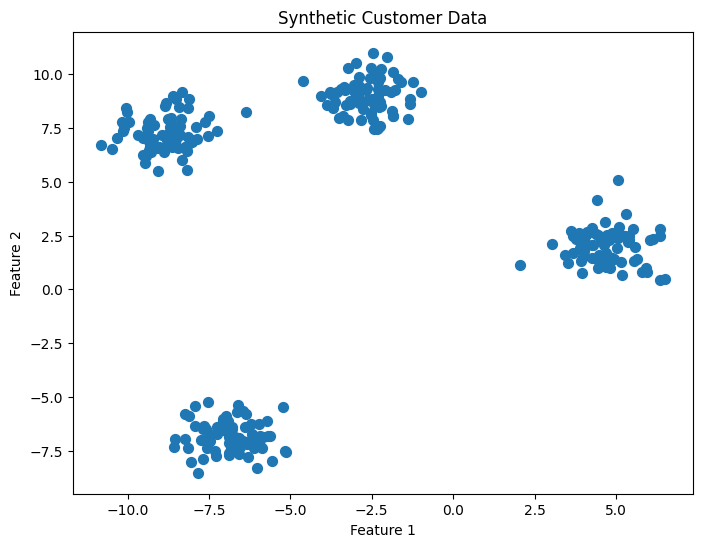

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generate synthetic data
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)

# Visualize the data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Synthetic Customer Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

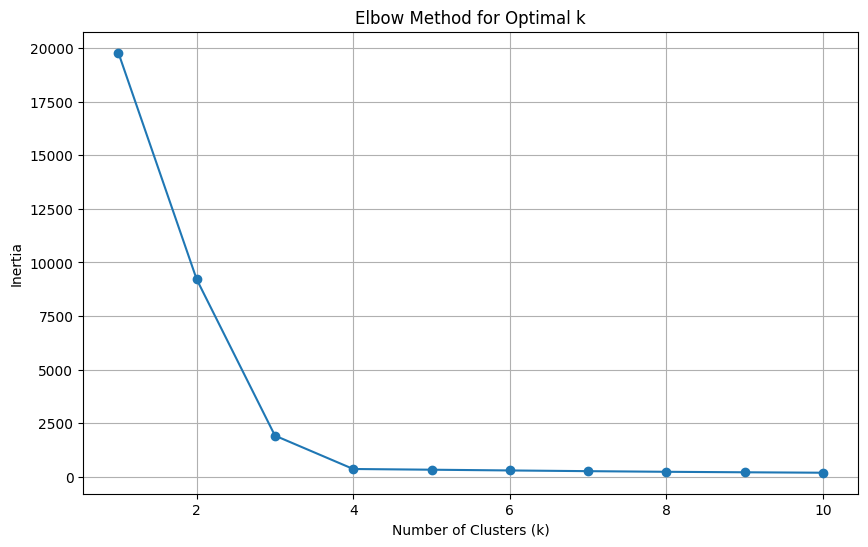

In [2]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Create an empty list to store the inertia values
inertia = []

# 2. Loop through k values from 1 to 10
for k in range(1, 11):
    # 3. Create and fit a KMeans model with `n_clusters=k`
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)

    # 4. Append the model's inertia_ to your list
    inertia.append(kmeans.inertia_)

# 5. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

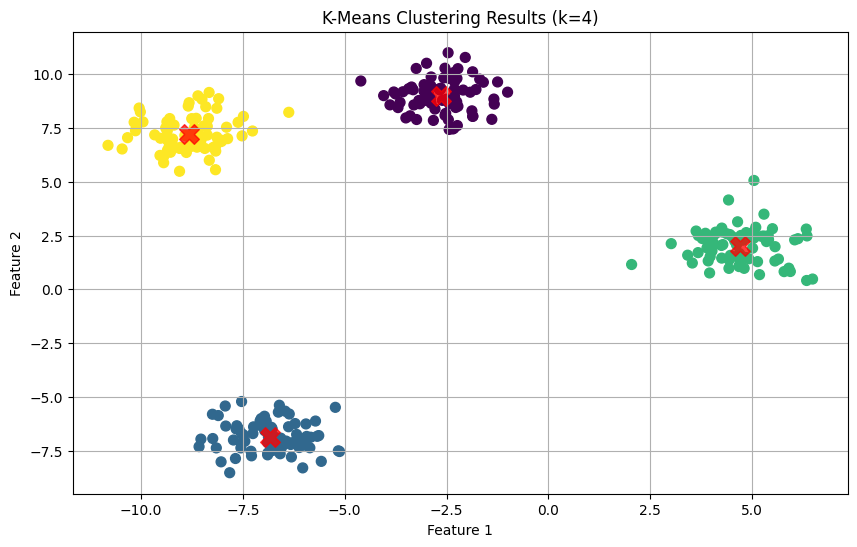

In [3]:
# 1. Create and fit a KMeans model with n_clusters=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X)

# 2. Get the cluster assignments for each data point
labels = kmeans.labels_

# 3. Get the coordinates of the cluster centers
centers = kmeans.cluster_centers_

# 4. Create a scatter plot of the data, colored by the labels
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X') # Plot the centers
plt.title('K-Means Clustering Results (k=4)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

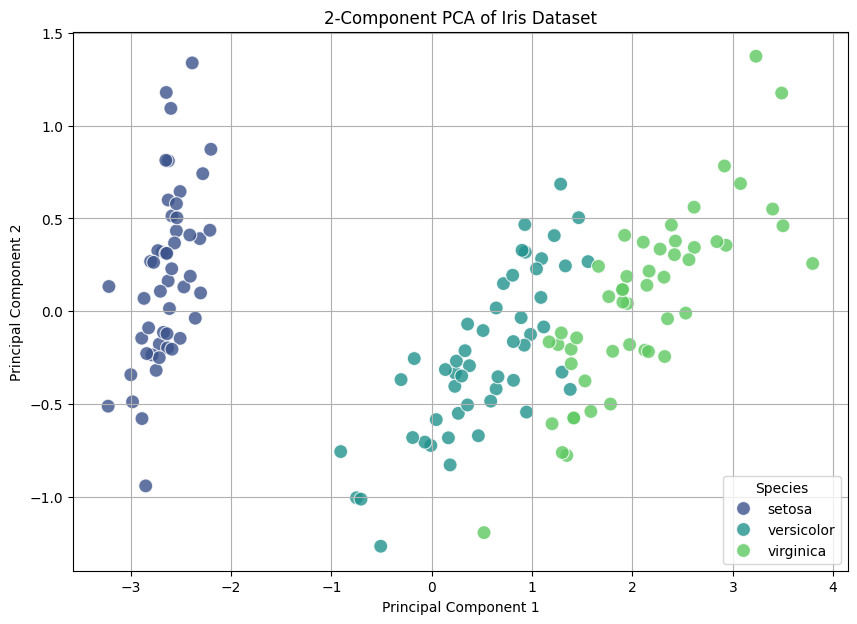

In [5]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn

# Load the data
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# 1. Create a PCA instance to reduce to 2 components
pca = PCA(n_components=2)

# 2. Fit PCA to the data and transform it
X_r = pca.fit(X_iris).transform(X_iris)

# 3. Create a DataFrame for easier plotting
# The target names will be used for the legend
target_names = iris.target_names
df_pca = pd.DataFrame(data=X_r, columns=['principal_component_1', 'principal_component_2'])
df_pca['target'] = y_iris
df_pca['target_name'] = df_pca['target'].apply(lambda x: target_names[x])

# 4. Visualize the result
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='principal_component_1',
    y='principal_component_2',
    hue='target_name',
    data=df_pca,
    palette='viridis',
    s=100,
    alpha=0.8
)
plt.title('2-Component PCA of Iris Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.legend(title='Species')
plt.show()

1.  The presence or absence of target labels (ground truth) during model training without target labels. In unsupervised learning the objective is to uncover underlying patterns, groupings, or structural relationships inherent in the data

2.  Doing so completely defeats the purpose of clustering: When every observation becomes its own cluster centroid, the model stores individual data points rather than discovering meaningful groups. Clustering seeks a balance between compactness (low inertia) and parsimony (a small, interpretable number of clusters).
3.  The original 4 features are strongly correlated with one another. The data effectively lies along a 2-dimensional subspace.